# Insulin and Glucagon Secretion as a Function of Glucose

This notebook plots the insulin and glucagon secretion rates as a function of glucose concentration, ignoring amino acid effects.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.optimize import curve_fit

# Secretion parameters from multi_nutrient_model_ext
I_max = 1.0       # Maximum insulin secretion
h_ins = 3.4       # Insulin secretion Hill coefficient
C_ins = 2.3       # Insulin secretion threshold (relative to glucose)

# Baseline glucose concentration
G_baseline = 6  # mM

# Load experimental glucagon-glucose raw data
glucagon_data = pd.read_csv('data/glucagon_glucose.csv')
GCG_max_pmol = glucagon_data['Glucagon_pmol_L'].max()
glucagon_data['glucagon_scaled'] = glucagon_data['Glucagon_pmol_L'] / GCG_max_pmol

print("Raw experimental data:")
print(glucagon_data)
print(f"\nNumber of data points: {len(glucagon_data)}")
print(f"\nSummary by condition:")
print(glucagon_data.groupby('Condition').agg({
    'Blood_glucose_mmol_L': ['mean', 'std', 'count'],
    'Glucagon_pmol_L': ['mean', 'std']
}).round(2))

Raw experimental data:
    Blood_glucose_mmol_L  Glucagon_pmol_L   Condition  glucagon_scaled
0                    2.4               27        Deep             0.54
1                    2.5               22        Deep             0.44
2                    2.6               35        Deep             0.70
3                    2.6               37        Deep             0.74
4                    2.7               38        Deep             0.76
5                    2.8               24        Deep             0.48
6                    2.9               39        Deep             0.78
7                    2.9               50        Deep             1.00
8                    3.3               28        Deep             0.56
9                    3.4               24        Deep             0.48
10                   3.3               12        Mild             0.24
11                   3.4               13        Mild             0.26
12                   3.4               15        Mild 

## Model Comparison using BIC

Testing different glucagon secretion models:
1. **Model 1 - Simple suppression (no Hill)**: $GCG = GCG_{max} \cdot \left(1 - \frac{G}{G + K}\right)$
2. **Model 2 - Hill suppression**: $GCG = GCG_{max} \cdot \left(1 - \frac{G^h}{G^h + K^h}\right)$
3. **Model 3 - Hill with alpha scaling**: $GCG = GCG_{max} \cdot \left(1 - \alpha \cdot \frac{G^h}{G^h + K^h}\right)$

In [2]:
# Define glucagon secretion models for comparison
# All models use G in relative units (G_mM / G_baseline)

def model1_simple(G_mM, GCG_max, K):
    """Simple suppression (no Hill): GCG = GCG_max * (1 - G/(G + K))"""
    G = G_mM / G_baseline
    return GCG_max * (1.0 - G / (G + K))

def model2_hill(G_mM, GCG_max, h, K):
    """Hill suppression: GCG = GCG_max * (1 - G^h/(G^h + K^h))"""
    G = G_mM / G_baseline
    return GCG_max * (1.0 - G**h / (G**h + K**h))

def model3_hill_alpha(G_mM, GCG_max, h, K, alpha):
    """Hill with alpha scaling: GCG = GCG_max * (1 - alpha * G^h/(G^h + K^h))"""
    G = G_mM / G_baseline
    return GCG_max * (1.0 - alpha * G**h / (G**h + K**h))

# Model specifications: (function, param_names, initial_guess, bounds)
models = {
    'M1: Simple': (model1_simple, ['GCG_max', 'K'], [1.0, 0.5], ([0.1, 0.01], [2.0, 5.0])),
    'M2: Hill': (model2_hill, ['GCG_max', 'h', 'K'], [1.0, 2.0, 0.5], ([0.1, 0.1, 0.01], [2.0, 10.0, 5.0])),
    'M3: Hill+α': (model3_hill_alpha, ['GCG_max', 'h', 'K', 'α'], [1.0, 2.0, 0.5, 0.5], ([0.1, 0.1, 0.01, 0.1], [2.0, 10.0, 5.0, 1.0])),
}

# BIC calculation: BIC = n*ln(RSS/n) + k*ln(n)
def calculate_bic(n_data, n_params, rss):
    """Calculate Bayesian Information Criterion"""
    return n_data * np.log(rss / n_data) + n_params * np.log(n_data)

# Fit all models and compute BIC using raw data (no weighting)
x_data = glucagon_data['Blood_glucose_mmol_L'].values
y_data = glucagon_data['glucagon_scaled'].values
n_data = len(x_data)

results = []

for model_name, (model_func, param_names, p0, bounds) in models.items():
    try:
        popt, pcov = curve_fit(model_func, x_data, y_data, 
                               p0=p0, bounds=bounds, 
                               maxfev=5000)
        perr = np.sqrt(np.diag(pcov))
        
        # Calculate residuals and RSS
        y_pred = model_func(x_data, *popt)
        rss = np.sum((y_data - y_pred)**2)
        
        # Calculate BIC and AIC
        n_params = len(popt)
        bic = calculate_bic(n_data, n_params, rss)
        aic = n_data * np.log(rss / n_data) + 2 * n_params  # AIC for comparison
        
        # R-squared
        ss_tot = np.sum((y_data - np.mean(y_data))**2)
        r_squared = 1 - rss / ss_tot
        
        results.append({
            'Model': model_name,
            'n_params': n_params,
            'params': dict(zip(param_names, popt)),
            'errors': dict(zip(param_names, perr)),
            'RSS': rss,
            'R²': r_squared,
            'BIC': bic,
            'AIC': aic,
            'popt': popt,
            'model_func': model_func
        })
        
    except Exception as e:
        print(f"Failed to fit {model_name}: {e}")

# Sort by BIC
results = sorted(results, key=lambda x: x['BIC'])

# Display results
print("="*80)
print("MODEL COMPARISON (sorted by BIC, lower is better)")
print("="*80)
print(f"{'Model':<18} {'k':>3} {'RSS':>10} {'R²':>8} {'BIC':>10} {'AIC':>10} {'ΔBIC':>8}")
print("-"*80)

best_bic = results[0]['BIC']
for r in results:
    delta_bic = r['BIC'] - best_bic
    print(f"{r['Model']:<18} {r['n_params']:>3} {r['RSS']:>10.4f} {r['R²']:>8.3f} {r['BIC']:>10.2f} {r['AIC']:>10.2f} {delta_bic:>8.2f}")

print("\n" + "="*80)
print("FITTED PARAMETERS")
print("="*80)
for r in results:
    print(f"\n{r['Model']}:")
    for param, val in r['params'].items():
        err = r['errors'][param]
        print(f"  {param} = {val:.3f} ± {err:.3f}")

MODEL COMPARISON (sorted by BIC, lower is better)
Model                k        RSS       R²        BIC        AIC     ΔBIC
--------------------------------------------------------------------------------
M2: Hill             3     0.6829    0.523    -131.99    -136.74     0.00
M3: Hill+α           4     0.6438    0.550    -130.52    -136.86     1.46
M1: Simple           2     0.7963    0.444    -130.04    -133.21     1.94

FITTED PARAMETERS

M2: Hill:
  GCG_max = 1.344 ± 1.912
  h = 1.954 ± 1.420
  K = 0.412 ± 0.571

M3: Hill+α:
  GCG_max = 0.694 ± 0.127
  h = 9.056 ± 7.285
  K = 0.564 ± 0.049
  α = 0.638 ± 0.124

M1: Simple:
  GCG_max = 2.000 ± 2.129
  K = 0.167 ± 0.230


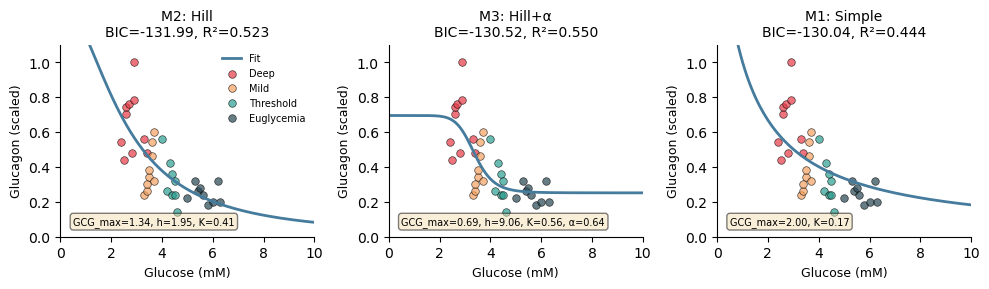


INTERPRETATION

Best model: M2: Hill
  - Uses 3 parameter(s)
  - BIC = -131.99
  - R² = 0.523

BIC interpretation (ΔBIC compared to best model):
  ΔBIC < 2:    Substantial support (models are comparable)
  ΔBIC 2-6:    Positive evidence against the model
  ΔBIC 6-10:   Strong evidence against the model
  ΔBIC > 10:   Very strong evidence against the model


In [3]:
# Plot all models with raw data
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes = axes.flatten()

G_mM_plot = np.linspace(0.1, 16.5, 200)
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

# Color mapping for conditions
condition_colors = {'Deep': '#E63946', 'Mild': '#F4A261', 'Threshold': '#2A9D8F', 'Euglycemia': '#264653'}

for i, r in enumerate(results):
    ax = axes[i]
    
    # Plot model fit
    y_fit = r['model_func'](G_mM_plot, *r['popt'])
    ax.plot(G_mM_plot, y_fit, color='#457B9D', linewidth=2, label='Fit')
    
    # Plot raw data points colored by condition
    for condition in glucagon_data['Condition'].unique():
        mask = glucagon_data['Condition'] == condition
        ax.scatter(glucagon_data.loc[mask, 'Blood_glucose_mmol_L'], 
                   glucagon_data.loc[mask, 'glucagon_scaled'],
                   c=condition_colors.get(condition, 'gray'), 
                   alpha=0.7, s=30, edgecolor='black', linewidth=0.5,
                   label=condition)
    
    # Add model info
    param_str = ', '.join([f"{k}={v:.2f}" for k, v in r['params'].items()])
    ax.set_title(f"{r['Model']}\nBIC={r['BIC']:.2f}, R²={r['R²']:.3f}", fontsize=10)
    ax.set_xlabel('Glucose (mM)', fontsize=9)
    ax.set_ylabel('Glucagon (scaled)', fontsize=9)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.1)
    ax.text(0.05, 0.05, param_str, transform=ax.transAxes, fontsize=7, 
            verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if i == 0:
        ax.legend(loc='upper right', fontsize=7, frameon=False)

plt.tight_layout()
sns.despine()
plt.savefig('output/glucagon_model_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

# Summary interpretation
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print(f"\nBest model: {results[0]['Model']}")
print(f"  - Uses {results[0]['n_params']} parameter(s)")
print(f"  - BIC = {results[0]['BIC']:.2f}")
print(f"  - R² = {results[0]['R²']:.3f}")

print("\nBIC interpretation (ΔBIC compared to best model):")
print("  ΔBIC < 2:    Substantial support (models are comparable)")
print("  ΔBIC 2-6:    Positive evidence against the model")
print("  ΔBIC 6-10:   Strong evidence against the model")
print("  ΔBIC > 10:   Very strong evidence against the model")

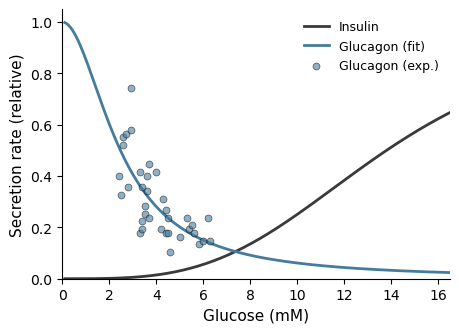


Code to update multi_nutrient_model_glucagon.py:

Best model: M2: Hill
Fitted GCG_max = 1.344 (used for renormalization)

Renormalized parameters (GCG_max = 1.0):
  GCG_max = 1.0 (renormalized)
  h = 1.95 ± 1.42
  K = 0.41 ± 0.57


In [4]:
# Final plot with best model and insulin
# Renormalize using fitted GCG_max
fig, ax = plt.subplots(figsize=(5, 3.5))

# Plot insulin secretion
G = G_mM_plot / G_baseline
insulin_secretion = I_max * G**h_ins / (G**h_ins + C_ins**h_ins)
ax.plot(G_mM_plot, insulin_secretion, label='Insulin', color="#3A3A3A", linewidth=2)

# Get best model and its GCG_max for renormalization
best = results[0]
GCG_max_fit = best['params']['GCG_max']

# Plot best glucagon model (renormalized by GCG_max)
glucagon_fit = best['model_func'](G_mM_plot, *best['popt']) / GCG_max_fit
ax.plot(G_mM_plot, glucagon_fit, label=f'Glucagon (fit)', color='#457B9D', linewidth=2)

# Add raw experimental data (renormalized by GCG_max) - single color
glucagon_data['glucagon_renorm'] = glucagon_data['glucagon_scaled'] / GCG_max_fit

ax.scatter(glucagon_data['Blood_glucose_mmol_L'], 
           glucagon_data['glucagon_renorm'],
           c='#457B9D', alpha=0.6, s=25, edgecolor='black', linewidth=0.5,
           label='Glucagon (exp.)', zorder=5)

ax.set_xlabel('Glucose (mM)', fontsize=11)
ax.set_ylabel('Secretion rate (relative)', fontsize=11)
ax.set_xlim(0, 16.5)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9, frameon=False)

#plt.xscale('log')

sns.despine()


plt.savefig('output/insulin_glucagon_secretion_best.svg', format='svg', bbox_inches='tight')
plt.show()

# Print code for updating the model
print("\n" + "="*60)
print("Code to update multi_nutrient_model_glucagon.py:")
print("="*60)
print(f"\nBest model: {best['Model']}")
print(f"Fitted GCG_max = {GCG_max_fit:.3f} (used for renormalization)")
print("\nRenormalized parameters (GCG_max = 1.0):")
for param, val in best['params'].items():
    err = best['errors'][param]
    if param == 'GCG_max':
        print(f"  {param} = 1.0 (renormalized)")
    else:
        print(f"  {param} = {val:.2f} ± {err:.2f}")

In [5]:
# GCG_0 absolute value bases on fitted GCG_max
GCG_0_absolute = GCG_max_fit * GCG_max_pmol
print(f"\nGCG_0 absolute value for model update: {GCG_0_absolute:.2f} pmol/L")


GCG_0 absolute value for model update: 67.22 pmol/L
